# Predicting Stellar Class — アンサンブルモデル

天体データから `GALAXY` / `QSO` / `STAR` の3クラスを予測する。

- **評価指標**: Balanced Accuracy
- **モデル**: LightGBM + XGBoost + CatBoost のアンサンブル(確率平均)
- **不均衡対策**: クラスバランス化したサンプル重みで学習
- **検証**: StratifiedKFold 3-fold のOOF評価

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

SEED = 42
N_FOLDS = 5

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
sample_sub = pd.read_csv("data/sample_submission.csv")

print(train.shape, test.shape)
train.head()

(577347, 12) (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


## 1. 簡単なEDA

クラス分布と、判別に効きそうな `redshift` の分布を確認する。

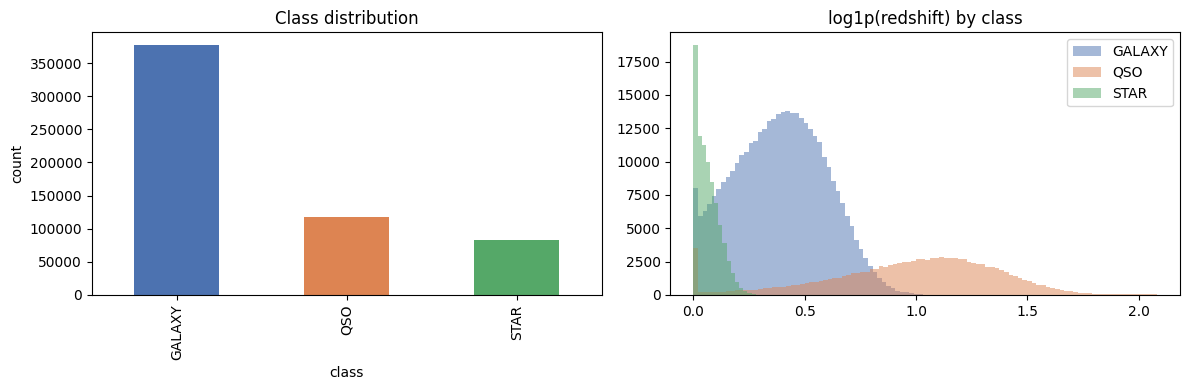

           count      mean       std       min       25%       50%       75%  \
class                                                                          
GALAXY  377480.0  0.509026  0.309139 -0.009934  0.267017  0.481960  0.715023   
QSO     117143.0  1.875641  1.069731  0.000100  1.131805  1.798886  2.506401   
STAR     82724.0  0.068115  0.064476 -0.009970  0.021884  0.056492  0.102069   

             max  
class             
GALAXY  6.860273  
QSO     7.010780  
STAR    5.445217  


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train["class"].value_counts().plot.bar(ax=axes[0], color=["#4c72b0", "#dd8452", "#55a868"])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("count")

for cls, color in zip(["GALAXY", "QSO", "STAR"], ["#4c72b0", "#dd8452", "#55a868"]):
    subset = train.loc[train["class"] == cls, "redshift"]
    axes[1].hist(np.log1p(subset.clip(lower=0)), bins=100, alpha=0.5, label=cls, color=color)
axes[1].set_title("log1p(redshift) by class")
axes[1].legend()

plt.tight_layout()
plt.show()

print(train.groupby("class")["redshift"].describe())

## 2. 特徴量エンジニアリング

- **色指数 (color index)**: 隣接バンドの等級差(`u-g`, `g-r`, `r-i`, `i-z`)は天体分類の定番特徴量
- 広いバンド間の差(`u-r`, `g-i`, `u-z`)も追加
- `redshift` は分布が裾広がりなので `log1p` 変換版も追加
- カテゴリ列(`spectral_type`, `galaxy_population`)はラベルエンコードし、LightGBM / CatBoost にはカテゴリとして渡す
- `alpha` / `delta`(天球座標)は本来クラスと無関係のはずだが、念のため残してモデルに判断させる

In [3]:
CAT_COLS = ["spectral_type", "galaxy_population"]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # 色指数(隣接バンド)
    out["u_g"] = out["u"] - out["g"]
    out["g_r"] = out["g"] - out["r"]
    out["r_i"] = out["r"] - out["i"]
    out["i_z"] = out["i"] - out["z"]
    # 広いバンド間
    out["u_r"] = out["u"] - out["r"]
    out["g_i"] = out["g"] - out["i"]
    out["u_z"] = out["u"] - out["z"]

    out["redshift_log1p"] = np.log1p(out["redshift"].clip(lower=0))

    return out


# カテゴリ列はtrain/test共通のエンコーダで数値化
cat_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    cat_encoders[col] = le

train_fe = build_features(train)
test_fe = build_features(test)
for col, le in cat_encoders.items():
    train_fe[col] = le.transform(train_fe[col])
    test_fe[col] = le.transform(test_fe[col])

FEATURES = [c for c in train_fe.columns if c not in ("id", "class")]

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(train_fe["class"])
X = train_fe[FEATURES]
X_test = test_fe[FEATURES]

# balanced accuracy向けにクラスバランス化した重み
sample_weight = compute_sample_weight("balanced", y)

print("features:", FEATURES)
print("classes:", list(target_encoder.classes_))

features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'g_i', 'u_z', 'redshift_log1p']
classes: ['GALAXY', 'QSO', 'STAR']


In [4]:
# --- Feature override: galactic coordinates + trig features ---
def equatorial_to_galactic(alpha_deg: np.ndarray, delta_deg: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # J2000 constants
    ra_ngp = np.deg2rad(192.85948)
    dec_ngp = np.deg2rad(27.12825)
    l_omega = np.deg2rad(32.93192)

    ra = np.deg2rad(alpha_deg)
    dec = np.deg2rad(delta_deg)

    sin_b = np.sin(dec) * np.sin(dec_ngp) + np.cos(dec) * np.cos(dec_ngp) * np.cos(ra - ra_ngp)
    b = np.arcsin(np.clip(sin_b, -1.0, 1.0))

    y_part = np.cos(dec) * np.sin(ra - ra_ngp)
    x_part = np.sin(dec) * np.cos(dec_ngp) - np.cos(dec) * np.sin(dec_ngp) * np.cos(ra - ra_ngp)
    l = np.arctan2(y_part, x_part) + l_omega
    l = np.mod(l, 2.0 * np.pi)

    return np.rad2deg(l), np.rad2deg(b)


def add_trig_pair(out: pd.DataFrame, col: str) -> None:
    rad = np.deg2rad(out[col].values)
    out[f"{col}_sin"] = np.sin(rad)
    out[f"{col}_cos"] = np.cos(rad)


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # color indices
    out["u_g"] = out["u"] - out["g"]
    out["g_r"] = out["g"] - out["r"]
    out["r_i"] = out["r"] - out["i"]
    out["i_z"] = out["i"] - out["z"]
    out["u_r"] = out["u"] - out["r"]
    out["g_i"] = out["g"] - out["i"]
    out["u_z"] = out["u"] - out["z"]

    out["redshift_log1p"] = np.log1p(out["redshift"].clip(lower=0))

    # galactic coords
    l_deg, b_deg = equatorial_to_galactic(out["alpha"].values, out["delta"].values)
    out["l"] = l_deg
    out["b"] = b_deg

    # periodic transforms
    for col in ["alpha", "delta", "l", "b"]:
        add_trig_pair(out, col)

    return out


# Rebuild encoded features with new build_features definition
cat_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    cat_encoders[col] = le

train_fe = build_features(train)
test_fe = build_features(test)
for col, le in cat_encoders.items():
    train_fe[col] = le.transform(train_fe[col])
    test_fe[col] = le.transform(test_fe[col])

FEATURES = [c for c in train_fe.columns if c not in ("id", "class")]

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(train_fe["class"])
X = train_fe[FEATURES]
X_test = test_fe[FEATURES]

sample_weight = compute_sample_weight("balanced", y)

print("features (overridden):", FEATURES)
print("n_features:", len(FEATURES))

features (overridden): ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'g_i', 'u_z', 'redshift_log1p', 'l', 'b', 'alpha_sin', 'alpha_cos', 'delta_sin', 'delta_cos', 'l_sin', 'l_cos', 'b_sin', 'b_cos']
n_features: 28


## 3. 学習(3-fold CV + 6モデル)

各foldで LightGBM / XGBoost / CatBoost / ExtraTrees / LightGBM(alt) / XGBoost(alt) を学習し、

- OOF(out-of-fold)予測確率 → アンサンブルの検証用
- テストデータへの予測確率(fold平均) → 提出用

をそれぞれ貯める。早期終了(early stopping)で過学習を抑える。

In [5]:
from catboost import Pool

N_CLASSES = len(target_encoder.classes_)
MODEL_NAMES = ["lgbm", "xgb", "cat", "et", "lgbm_alt", "xgb_alt"]

oof = {m: np.zeros((len(X), N_CLASSES)) for m in MODEL_NAMES}
pred_test = {m: np.zeros((len(X_test), N_CLASSES)) for m in MODEL_NAMES}

# fold内バイアス最適化用に、foldごとの予測を保持
oof_fold = {m: [] for m in MODEL_NAMES}
pred_test_fold = {m: [] for m in MODEL_NAMES}
va_indices = []
y_valid_folds = []

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]
    w_tr, w_va = sample_weight[tr_idx], sample_weight[va_idx]

    # ---- LightGBM ----
    lgbm_model = lgb.LGBMClassifier(
        objective="multiclass",
        n_estimators=2000,
        learning_rate=0.05,
        num_leaves=127,
        colsample_bytree=0.8,
        subsample=0.8,
        subsample_freq=1,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )
    lgbm_model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        eval_sample_weight=[w_va],
        categorical_feature=CAT_COLS,
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    lgbm_va = lgbm_model.predict_proba(X_va)
    lgbm_test = lgbm_model.predict_proba(X_test)
    oof["lgbm"][va_idx] = lgbm_va
    pred_test["lgbm"] += lgbm_test / N_FOLDS
    oof_fold["lgbm"].append(lgbm_va)
    pred_test_fold["lgbm"].append(lgbm_test)

    # ---- XGBoost ----
    xgb_model = xgb.XGBClassifier(
        objective="multi:softprob",
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=8,
        colsample_bytree=0.8,
        subsample=0.8,
        tree_method="hist",
        device="cuda",
        early_stopping_rounds=100,
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )
    xgb_model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        sample_weight_eval_set=[w_va],
        verbose=False,
    )
    xgb_va = xgb_model.predict_proba(X_va)
    xgb_test = xgb_model.predict_proba(X_test)
    oof["xgb"][va_idx] = xgb_va
    pred_test["xgb"] += xgb_test / N_FOLDS
    oof_fold["xgb"].append(xgb_va)
    pred_test_fold["xgb"].append(xgb_test)

    # ---- CatBoost ----
    cat_feature_idx = [FEATURES.index(c) for c in CAT_COLS]
    cat_model = CatBoostClassifier(
        loss_function="MultiClass",
        iterations=2000,
        learning_rate=0.08,
        depth=8,
        random_seed=SEED,
        early_stopping_rounds=100,
        task_type="GPU",
        devices="0",
        verbose=0,
    )
    cat_model.fit(
        Pool(X_tr, y_tr, weight=w_tr, cat_features=cat_feature_idx),
        eval_set=Pool(X_va, y_va, weight=w_va, cat_features=cat_feature_idx),
    )
    cat_va = cat_model.predict_proba(X_va)
    cat_test = cat_model.predict_proba(X_test)
    oof["cat"][va_idx] = cat_va
    pred_test["cat"] += cat_test / N_FOLDS
    oof_fold["cat"].append(cat_va)
    pred_test_fold["cat"].append(cat_test)

    # ---- ExtraTrees ----
    et_model = ExtraTreesClassifier(
        n_estimators=600,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=SEED,
    )
    et_model.fit(X_tr, y_tr, sample_weight=w_tr)
    et_va = et_model.predict_proba(X_va)
    et_test = et_model.predict_proba(X_test)
    oof["et"][va_idx] = et_va
    pred_test["et"] += et_test / N_FOLDS
    oof_fold["et"].append(et_va)
    pred_test_fold["et"].append(et_test)

    # ---- LightGBM (alt) ----
    lgbm_alt_model = lgb.LGBMClassifier(
        objective="multiclass",
        n_estimators=2200,
        learning_rate=0.04,
        num_leaves=255,
        max_depth=-1,
        min_child_samples=40,
        colsample_bytree=0.9,
        subsample=0.9,
        subsample_freq=1,
        random_state=SEED + 101,
        n_jobs=-1,
        verbosity=-1,
    )
    lgbm_alt_model.fit(
        X_tr,
        y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        eval_sample_weight=[w_va],
        categorical_feature=CAT_COLS,
        callbacks=[lgb.early_stopping(120, verbose=False), lgb.log_evaluation(0)],
    )
    lgbm_alt_va = lgbm_alt_model.predict_proba(X_va)
    lgbm_alt_test = lgbm_alt_model.predict_proba(X_test)
    oof["lgbm_alt"][va_idx] = lgbm_alt_va
    pred_test["lgbm_alt"] += lgbm_alt_test / N_FOLDS
    oof_fold["lgbm_alt"].append(lgbm_alt_va)
    pred_test_fold["lgbm_alt"].append(lgbm_alt_test)

    # ---- XGBoost (alt) ----
    xgb_alt_model = xgb.XGBClassifier(
        objective="multi:softprob",
        n_estimators=2200,
        learning_rate=0.04,
        max_depth=10,
        min_child_weight=2,
        gamma=0.0,
        colsample_bytree=0.9,
        subsample=0.9,
        tree_method="hist",
        device="cuda",
        early_stopping_rounds=120,
        random_state=SEED + 202,
        n_jobs=-1,
        verbosity=0,
    )
    xgb_alt_model.fit(
        X_tr,
        y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        sample_weight_eval_set=[w_va],
        verbose=False,
    )
    xgb_alt_va = xgb_alt_model.predict_proba(X_va)
    xgb_alt_test = xgb_alt_model.predict_proba(X_test)
    oof["xgb_alt"][va_idx] = xgb_alt_va
    pred_test["xgb_alt"] += xgb_alt_test / N_FOLDS
    oof_fold["xgb_alt"].append(xgb_alt_va)
    pred_test_fold["xgb_alt"].append(xgb_alt_test)

    va_indices.append(va_idx)
    y_valid_folds.append(y_va)

    scores = {
        m: balanced_accuracy_score(y_va, oof[m][va_idx].argmax(axis=1))
        for m in MODEL_NAMES
    }
    print(f"fold {fold}: " + ", ".join(f"{m}={s:.5f}" for m, s in scores.items()))

for m in MODEL_NAMES:
    print(f"OOF balanced accuracy [{m}]: {balanced_accuracy_score(y, oof[m].argmax(axis=1)):.5f}")

fold 0: lgbm=0.96663, xgb=0.96662, cat=0.96452, et=0.95313, lgbm_alt=0.96558, xgb_alt=0.96510


fold 1: lgbm=0.96626, xgb=0.96583, cat=0.96394, et=0.95420, lgbm_alt=0.96579, xgb_alt=0.96505


fold 2: lgbm=0.96539, xgb=0.96499, cat=0.96342, et=0.95311, lgbm_alt=0.96518, xgb_alt=0.96480


fold 3: lgbm=0.96585, xgb=0.96534, cat=0.96425, et=0.95327, lgbm_alt=0.96509, xgb_alt=0.96426


fold 4: lgbm=0.96612, xgb=0.96585, cat=0.96431, et=0.95379, lgbm_alt=0.96547, xgb_alt=0.96464
OOF balanced accuracy [lgbm]: 0.96605
OOF balanced accuracy [xgb]: 0.96573
OOF balanced accuracy [cat]: 0.96409
OOF balanced accuracy [et]: 0.95350
OOF balanced accuracy [lgbm_alt]: 0.96542
OOF balanced accuracy [xgb_alt]: 0.96477


## 4. アンサンブル

6モデルの予測確率を重み付き平均する。重みはOOFのbalanced accuracyが最大になる組み合わせをグリッドサーチで決める。

n_weight_candidates: 3003
best weights (lgbm, xgb, cat, et, lgbm_alt, xgb_alt) = (0.5, 0.4, 0.1, 0.0, 0.0, 0.0)
ensemble OOF balanced accuracy (base) = 0.96631


fold 0 best bias = [-0.06, 0.05000000000000002, 0.030000000000000027], score = 0.96718


fold 1 best bias = [-0.06, 0.030000000000000027, 0.060000000000000026], score = 0.96656


fold 2 best bias = [-0.01999999999999999, -0.06, 0.05000000000000002], score = 0.96583


fold 3 best bias = [-0.06, -0.01999999999999999, 0.04000000000000002], score = 0.96640


fold 4 best bias = [-0.06, -0.049999999999999996, 0.05000000000000002], score = 0.96689
ensemble OOF balanced accuracy (bias-corrected) = 0.96657
mean fold bias: [-0.052000000000000005, -0.009999999999999988, 0.04600000000000003]


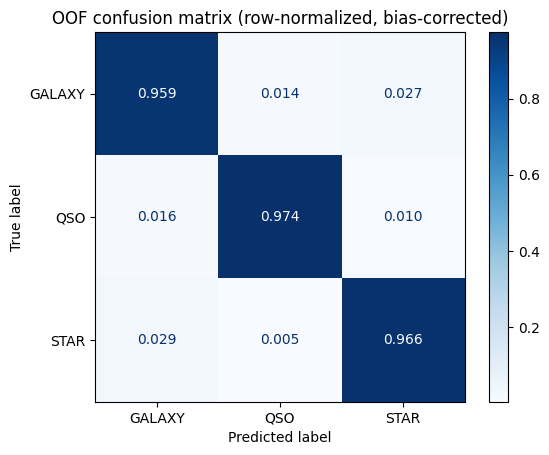

In [6]:
from itertools import product

# 1) モデル重みをOOFで最適化（6モデルでも実用速度になるよう候補を直接生成）
def generate_weight_candidates(num_models, total_steps=10):
    if num_models == 1:
        yield (total_steps,)
        return
    for i in range(total_steps + 1):
        for tail in generate_weight_candidates(num_models - 1, total_steps - i):
            yield (i,) + tail


best_weights, best_score = None, -1.0
weight_step = 0.1
weight_candidates = [tuple(v * weight_step for v in ints) for ints in generate_weight_candidates(len(MODEL_NAMES), int(round(1.0 / weight_step)))]

for weights in weight_candidates:
    blend = sum(w * oof[m] for w, m in zip(weights, MODEL_NAMES))
    score = balanced_accuracy_score(y, blend.argmax(axis=1))
    if score > best_score:
        best_score = score
        best_weights = weights

print("n_weight_candidates:", len(weight_candidates))
print(f"best weights ({', '.join(MODEL_NAMES)}) = {best_weights}")
print(f"ensemble OOF balanced accuracy (base) = {best_score:.5f}")

# 2) foldごとにバイアス最適化（log(prob)+bias）
def find_best_bias(log_proba, y_true, bias_grid):
    best_bias = np.zeros(log_proba.shape[1])
    best_score_local = -1.0
    for bias in product(bias_grid, repeat=log_proba.shape[1]):
        bias = np.array(bias)
        pred_tmp = (log_proba + bias).argmax(axis=1)
        s = balanced_accuracy_score(y_true, pred_tmp)
        if s > best_score_local:
            best_score_local = s
            best_bias = bias.copy()
    return best_bias, best_score_local


def apply_log_bias_to_proba(proba, bias):
    adj = np.exp(np.log(np.clip(proba, 1e-15, 1.0)) + bias)
    return adj / adj.sum(axis=1, keepdims=True)


oof_blend_base = sum(w * oof[m] for w, m in zip(best_weights, MODEL_NAMES))
oof_pred_base = oof_blend_base.argmax(axis=1)

bias_grid = np.arange(-0.06, 0.061, 0.01)
fold_biases = []

oof_blend_bias = np.zeros((len(X), N_CLASSES))
test_blend_bias = np.zeros((len(X_test), N_CLASSES))

for fold in range(N_FOLDS):
    va_idx = va_indices[fold]
    y_va = y_valid_folds[fold]

    va_blend = sum(w * oof_fold[m][fold] for w, m in zip(best_weights, MODEL_NAMES))
    test_blend_fold = sum(w * pred_test_fold[m][fold] for w, m in zip(best_weights, MODEL_NAMES))

    best_bias, best_score_fold = find_best_bias(np.log(np.clip(va_blend, 1e-15, 1.0)), y_va, bias_grid)
    fold_biases.append(best_bias)

    oof_blend_bias[va_idx] = apply_log_bias_to_proba(va_blend, best_bias)
    test_blend_bias += apply_log_bias_to_proba(test_blend_fold, best_bias) / N_FOLDS

    print(f"fold {fold} best bias = {best_bias.tolist()}, score = {best_score_fold:.5f}")

oof_pred = oof_blend_bias.argmax(axis=1)
score_bias = balanced_accuracy_score(y, oof_pred)

print(f"ensemble OOF balanced accuracy (bias-corrected) = {score_bias:.5f}")
print("mean fold bias:", np.mean(np.stack(fold_biases), axis=0).tolist())

# 提出時に使う最終ブレンド（fold内バイアス補正済み）
test_blend = test_blend_bias

cm = confusion_matrix(y, oof_pred, normalize="true")
disp = ConfusionMatrixDisplay(cm, display_labels=target_encoder.classes_)
disp.plot(cmap="Blues", values_format=".3f")
plt.title("OOF confusion matrix (row-normalized, bias-corrected)")
plt.show()

## 5. スタッキング（OOFメタ学習）

6モデルのOOF確率を特徴量として、2層目のロジスティック回帰を学習する。
メタ層もfoldで学習し、OOFとtest予測を作る。

## 6. 提出ファイル作成

スタッキングで得た `test_blend` から最終クラスを作成して `submission.csv` を出力する。

C:\Users\yusuke\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C:\Users\yusuke\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C:\Users\yusuke\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C:\Users\yusuke\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C:\Users\yusuke\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


stacking OOF balanced accuracy = 0.96581


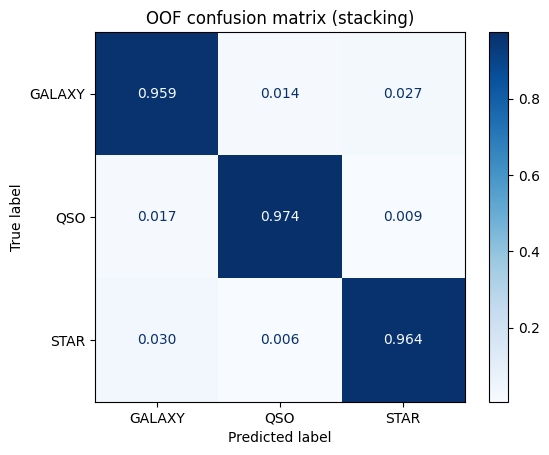

class
GALAXY    157361
QSO        51240
STAR       38834
Name: count, dtype: int64


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


In [7]:
# OOF確率をメタ特徴量へ変換
meta_features = np.concatenate([oof[m] for m in MODEL_NAMES], axis=1)
meta_test_features = np.concatenate([pred_test[m] for m in MODEL_NAMES], axis=1)

# メタ層CV（リーク回避のためfoldで学習）
meta_oof = np.zeros((len(X), N_CLASSES))
meta_test = np.zeros((len(X_test), N_CLASSES))

meta_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED + 999)
for fold, (tr_idx, va_idx) in enumerate(meta_skf.split(meta_features, y)):
    X_meta_tr, X_meta_va = meta_features[tr_idx], meta_features[va_idx]
    y_meta_tr, y_meta_va = y[tr_idx], y[va_idx]

    meta_model = LogisticRegression(
        max_iter=4000,
        multi_class="multinomial",
        class_weight="balanced",
        n_jobs=-1,
        C=2.0,
        random_state=SEED + 999 + fold,
    )
    meta_model.fit(X_meta_tr, y_meta_tr)

    meta_oof[va_idx] = meta_model.predict_proba(X_meta_va)
    meta_test += meta_model.predict_proba(meta_test_features) / N_FOLDS

meta_score = balanced_accuracy_score(y, meta_oof.argmax(axis=1))
print(f"stacking OOF balanced accuracy = {meta_score:.5f}")

# スタッキング結果を最終提出に使用
test_blend = meta_test

cm_stack = confusion_matrix(y, meta_oof.argmax(axis=1), normalize="true")
disp_stack = ConfusionMatrixDisplay(cm_stack, display_labels=target_encoder.classes_)
disp_stack.plot(cmap="Blues", values_format=".3f")
plt.title("OOF confusion matrix (stacking)")
plt.show()

test_pred = target_encoder.inverse_transform(test_blend.argmax(axis=1))

submission = pd.DataFrame({"id": test_fe["id"], "class": test_pred})
assert (submission["id"].values == sample_sub["id"].values).all()
submission.to_csv("submission.csv", index=False)

print(submission["class"].value_counts())
submission.head()